In [280]:
import ee
# from rich.jupyter import display
# from sympy.stats.sampling.sample_numpy import numpy

ee.Authenticate()

True

In [281]:
ee.Initialize(project="climateconsciousimli")  # assumes you've authenticated already

In [282]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
# import torch
import numpy as np

In [283]:
# Define bounding box (lon_min, lat_min, lon_max, lat_max)
lat_min, lat_max = 28.0, 29.39
lat_avg = (lat_max + lat_min) / 2
lon_min, lon_max = 76.3, 79.0
lon_avg = (lon_max + lon_min) / 2

stepp = 0.25


roi = ee.Geometry.Rectangle([lon_min, lat_min, lon_max, lat_max])
pixel = ee.Geometry.Point([77.0, 29.0])
micropixel = ee.Geometry.Rectangle([lon_avg-stepp, lat_avg-stepp, lon_avg+stepp, lat_avg+stepp])
sampling_scale = 5100
start_date = '2024-02-01'
end_date = '2024-02-04'

- Everything is the same till now.
- `scale` is \~8km.
- `pixel` is one point.
- `roi` is the region.
- `micropixel` is a smaller region to make computation easier
- Now collect the data accordingly :

In [284]:
"""
Can define multiple collections (wind, SO2, NO2). Prepare what we're doing for each. Then feed outputs for all. No merging required as such, except right before training/input into a model.
"""

collection = (
    ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_NO2")
    .filterBounds(roi)# REPLACE WITH ROI
    .filterDate(start_date, end_date)
    .select('tropospheric_NO2_column_number_density')
)

- The function `make_coarse` given below is of interest. In words (which I myself don't fully understand yet), it takes in raw data, reduces its resolution by taking a mean (how is that done/executed?). It then "reprojeccts" the data, with some scale in mind, giving us the "coarse" data.
- The raw data has each pixel representing ~7km$^2$. We do not wish to work with this. To "access" the data, we call several functions :
-   `reduceResolution`
-   `reproject` onto the grid.
-   `focal_mean` : treat "Null" by taking a spatial mean.
-   `copyProperties` : preserves `system:time_start`.

In [285]:
def make_coarse(image):
    return (image
        .reduceResolution(
            reducer=ee.Reducer.mean(),
            bestEffort=True
        )
        .reproject(
            scale=1100,
            crs='EPSG:4326'
        )#.focal_mean(radius=4, units='pixels')
        .copyProperties(image, ['system:time_start'])
    )

coarse_collection = collection.map(make_coarse) # This (possibly coarse) collection will be henceforth be used.

size_of_coll = coarse_collection.size().getInfo()
print(f"Size of collection is {size_of_coll}. In particular, coarse_collection.getInfo()['features'] has that many items.")
print()
print(f"This means we have ~{size_of_coll} entries in the given time range. For each of these, we have an image (11px by 11px) of the entire region we have (after reducing resolution) So if we have {size_of_coll} measurements for the region, and the region is (say) 11*11 pixels, then we have ~{11*11*size_of_coll} measurements. Many of these may be null!")
# print(coarse_collection.first().getInfo()['properties']['system:time_start']) # need to parse as date-time

Size of collection is 42. In particular, coarse_collection.getInfo()['features'] has that many items.

This means we have ~42 entries in the given time range. For each of these, we have an image (11px by 11px) of the entire region we have (after reducing resolution) So if we have 42 measurements for the region, and the region is (say) 11*11 pixels, then we have ~5082 measurements. Many of these may be null!


In [286]:
def sample_image(image):
    samples = image.sample(
        region=roi,
        scale=sampling_scale,
        geometries=True,
        dropNulls=True
    )
    # return samples.map(lambda f: f.set('system:time_start', f.getInfo()['properties']['system:time_start'])).map(lambda f: f.set(
    #     'date', image.date().format('YYYY-MM-dd')
    # ))
    time_start = image.get('system:time_start')
    return samples.map(lambda f: f.set({
        # 'system:time_start': time_start,
        'date': ee.Date(time_start).format('YYYY-MM-dd'),
        'datetime': ee.Date(time_start).format('YYYY-MM-dd HH:mm:ss')
    }))

fc = coarse_collection.map(sample_image).flatten()
print(f"Now we have reduced our region of interest from roi to micropixel or pixel. We retain null values and the data we keep is as below :")

Now we have reduced our region of interest from roi to micropixel or pixel. We retain null values and the data we keep is as below :


In [287]:
features = fc.getInfo()['features']
# print(f"Features are : \n\n{features}\n\n")
proppies = features[0]['properties'] # ['tropospheric_NO2_column_number_density'])
print(f"Following is 'fc.getInfo()['features'][0]['properties']', that is, the properties relating to the first (hence `0`) feature that we have. One can expect to see date, date-time, and NO2 value (if not null) : \n\n{proppies}\n\n")
print()
print(f"proppies.get('tropospheric_NO2_column_number_density') gives {proppies.get('tropospheric_NO2_column_number_density')}")
print("This applies for proppies being the first record in the given time range. Now we will try them all out ....\n\n\n")


n_feature_instances = len(features)
print(f"number of 'features' is {n_feature_instances}, as we calculated above.")
print(features[0].get('properties'))
for i in range(n_feature_instances):
    print(features[i]['properties'].get('tropospheric_NO2_column_number_density'), features[i]['properties'].get('datetime'))
# for j in proppies:
#     print(j)
#     print()

Following is 'fc.getInfo()['features'][0]['properties']', that is, the properties relating to the first (hence `0`) feature that we have. One can expect to see date, date-time, and NO2 value (if not null) : 

{'date': '2024-02-01', 'datetime': '2024-02-01 06:45:46', 'tropospheric_NO2_column_number_density': 3.238481851497905e-05}



proppies.get('tropospheric_NO2_column_number_density') gives 3.238481851497905e-05
This applies for proppies being the first record in the given time range. Now we will try them all out ....



number of 'features' is 3558, as we calculated above.
{'date': '2024-02-01', 'datetime': '2024-02-01 06:45:46', 'tropospheric_NO2_column_number_density': 3.238481851497905e-05}
3.238481851497905e-05 2024-02-01 06:45:46
3.6529599460607315e-05 2024-02-01 06:45:46
2.6422457569403447e-05 2024-02-01 06:45:46
3.652959923610502e-05 2024-02-01 06:45:46
2.6422458149087545e-05 2024-02-01 06:45:46
2.6422457863180074e-05 2024-02-01 06:45:46
3.3601576092890506e-05 2024-02-01 06:4

In [288]:
features = fc.getInfo()['features']

rows = []
for f in features:
    props = f['properties']
    coords = f['geometry']['coordinates']

    if 'tropospheric_NO2_column_number_density' in props:
        rows.append({
            'lon': coords[0],
            'lat': coords[1],
            'date': props['date'],
            'datetime': props['datetime'],
            'NO2': props['tropospheric_NO2_column_number_density']
        })

df = pd.DataFrame(rows)
df

,lon,lat,date,datetime,NO2
0,78.502425,29.389732,2024-02-01,2024-02-01 06:45:46,0.000032
1,78.548239,29.389732,2024-02-01,2024-02-01 06:45:46,0.000037
2,78.639867,29.389732,2024-02-01,2024-02-01 06:45:46,0.000026
3,78.502425,29.343918,2024-02-01,2024-02-01 06:45:46,0.000037
4,78.594053,29.343918,2024-02-01,2024-02-01 06:45:46,0.000026
...,...,...,...,...,...
3553,78.777310,28.015310,2024-02-03,2024-02-03 07:49:22,0.000021
3554,78.823124,28.015310,2024-02-03,2024-02-03 07:49:22,0.000030
3555,78.868938,28.015310,2024-02-03,2024-02-03 07:49:22,0.000016
3556,78.914752,28.015310,2024-02-03,2024-02-03 07:49:22,0.000005


In [289]:
unique_dates = sorted(df['date'].unique())
print(len(df['date']))
selected_dates = unique_dates[:]

3558


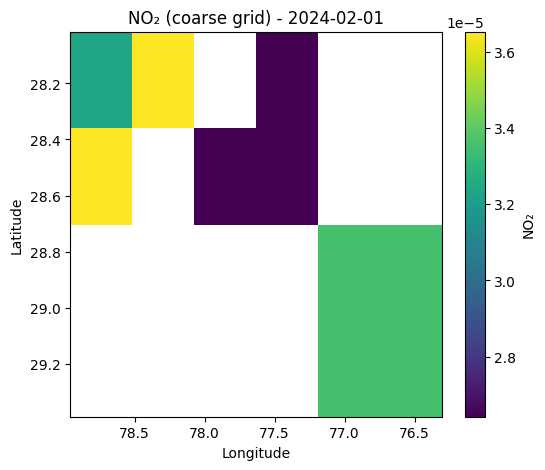

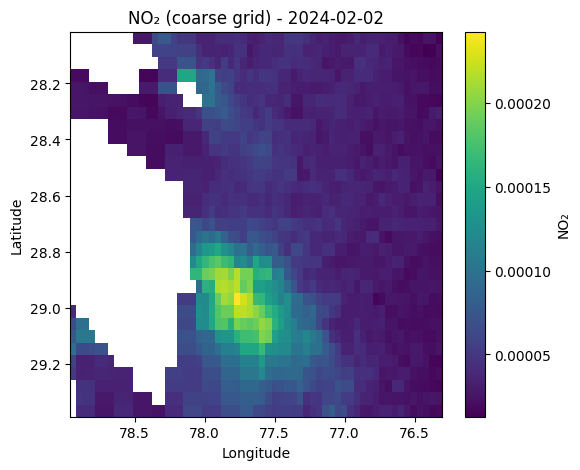

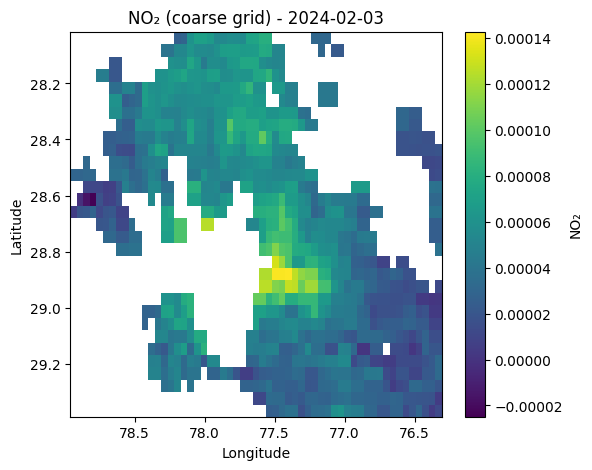

29.38973199289633 28.015309608193462
78.96056600117977 76.30334939075422


In [290]:
latt = []
lonn = []

for d in selected_dates:
    subset = df[df['date'] == d].copy()

    # Create grid
    pivot = subset.pivot_table(
        index='lat',
        columns='lon',
        values='NO2'
    )
    pivot.fillna(0)

    plt.figure(figsize=(6,5))
    plt.imshow(
        pivot.values,
        extent=(
            78.96056600117977, 76.30334939075422,
            29.38973199289633, 28.015309608193462
            # pivot.columns.min(), pivot.columns.max(),
            # pivot.index.min(), pivot.index.max()
        ),
        origin='lower',
        aspect='auto'
    )
    lonn += [pivot.columns.min(), pivot.columns.max()]
    latt += [pivot.index.min(), pivot.index.max()]
    plt.colorbar(label='NO₂')
    plt.title(f'NO₂ (coarse grid) - {d}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

print(max(latt), min(latt))
print(max(lonn), min(lonn))

In [291]:
# import pandas as pd
# import numpy as np

# 1. Create a copy and ensure datetime types
df_interp = df.copy()
df_interp['datetime'] = pd.to_datetime(df_interp['datetime'])

# 2. Create complete grid
all_lats = df_interp['lat'].unique()
all_lons = df_interp['lon'].unique()
all_times = sorted(df_interp['datetime'].unique())
# print(all_times)
# index = pd.MultiIndex.from_product([all_lats, all_lons, all_times], names=['lat', 'lon', 'datetime'])
# full_df = pd.DataFrame(index=index).reset_index()

index = pd.MultiIndex.from_product([all_lats, all_lons, all_times], names=['lat', 'lon', 'datetime'])
full_df = pd.DataFrame(index=index).reset_index()

# Merge original data
df_merged = pd.merge(full_df, df_interp, on=['lat', 'lon', 'datetime'], how='left')
df_merged = df_merged.sort_values(['lat', 'lon', 'date'])


df_merged['date'] = (df_merged['datetime']).dt.date

# 3. Interpolate NO2 values
# df_merged['NO2_interpolated'] = df_merged.groupby(['lat', 'lon'])['NO2'].transform(
#     lambda x: x.interpolate(method='linear', limit_direction='both').bfill().ffill()
# )

print("Original row count:", len(df))
print("Expanded row count:", len(df_merged))
print("Example of filled dates:")
# df_interpolated = df_merged.fillna(0)
df_merged

Original row count: 3558
Expanded row count: 7316
Example of filled dates:


,lat,lon,datetime,date,NO2
7276,28.015310,76.303349,2024-02-01 06:45:46,2024-02-01,NaN
7277,28.015310,76.303349,2024-02-02 06:26:49,2024-02-02,NaN
7278,28.015310,76.303349,2024-02-02 08:08:19,2024-02-02,NaN
7279,28.015310,76.303349,2024-02-03 07:49:22,2024-02-03,NaN
7282,28.015310,76.349163,2024-02-02 08:08:19,2024-02-02,0.000041
...,...,...,...,...,...
151,29.389732,78.914752,2024-02-03 07:49:22,2024-02-03,NaN
153,29.389732,78.960566,2024-02-02 06:26:49,2024-02-02,0.000010
154,29.389732,78.960566,2024-02-02 08:08:19,2024-02-02,0.000016
152,29.389732,78.960566,2024-02-01 06:45:46,2024-02-01,NaN


In [292]:
# # Example: assuming df_merged has 'date', 'datetime', 'lat', 'lon', 'NO2'
# # Make sure 'datetime' is actually a datetime object
# # df_merged['date'] = pd.to_datetime(df_merged['date'])
# df_merged['date'] = pd.to_datetime(df_merged['date']).dt.date  # keep only date for plotting

# # Step 1-4: Group, sort, interpolate, ffill, bfill, and ungroup
# def interpolate_group(group):
#     # print(group.head(2))
#     # Sort by date
#     group = group.sort_values('date')
#     # Linear interpolation
#     group['NO2'] = group['NO2'].interpolate(method='linear')
#     # Forward fill and backward fill
#     group['NO2'] = group['NO2'].ffill().bfill()
#     return group

# df_interpolated = df_merged.groupby(['lat', 'lon'], group_keys=False)
# print("hello?")
# print(df_interpolated('date').head(2))
# print("\n\n\nhahahahahahah \n\n\n\n")
# print()
# print()

# colss = df_interpolated.sort_values('date')[['lat', 'lon']]

# df_interpolated = df_interpolated.apply(interpolate_group)
# df_interpolated[['lat,lon']] = colss.values
# print(df_interpolated.head(5))
# # Step 5: Plot lat-lon graphs for each date
# dates = df_interpolated['date'].unique()
# for d in dates:
#     daily_data = df_interpolated[df_interpolated['date'] == d]
    
#     plt.figure(figsize=(8,6))
#     sc = plt.scatter(daily_data['lon'], daily_data['lat'], c=daily_data['NO2'], cmap='viridis')
#     plt.colorbar(sc, label='NO2')
#     plt.xlabel('Longitude')
#     plt.ylabel('Latitude')
#     plt.title(f'NO2 levels on {d}')
#     plt.show()

            lat        lon            datetime        date       NO2
7276  28.015310  76.303349 2024-02-01 06:45:46  2024-02-01       NaN
7277  28.015310  76.303349 2024-02-02 06:26:49  2024-02-02       NaN
7278  28.015310  76.303349 2024-02-02 08:08:19  2024-02-02       NaN
7279  28.015310  76.303349 2024-02-03 07:49:22  2024-02-03       NaN
7282  28.015310  76.349163 2024-02-02 08:08:19  2024-02-02  0.000041
...         ...        ...                 ...         ...       ...
151   29.389732  78.914752 2024-02-03 07:49:22  2024-02-03       NaN
153   29.389732  78.960566 2024-02-02 06:26:49  2024-02-02  0.000010
154   29.389732  78.960566 2024-02-02 08:08:19  2024-02-02  0.000016
152   29.389732  78.960566 2024-02-01 06:45:46  2024-02-01       NaN
155   29.389732  78.960566 2024-02-03 07:49:22  2024-02-03       NaN

[7316 rows x 5 columns]


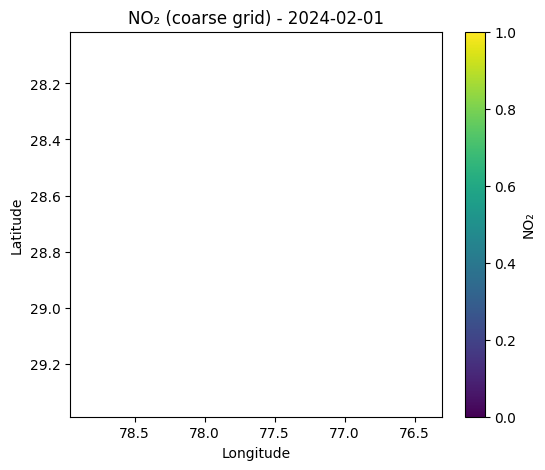

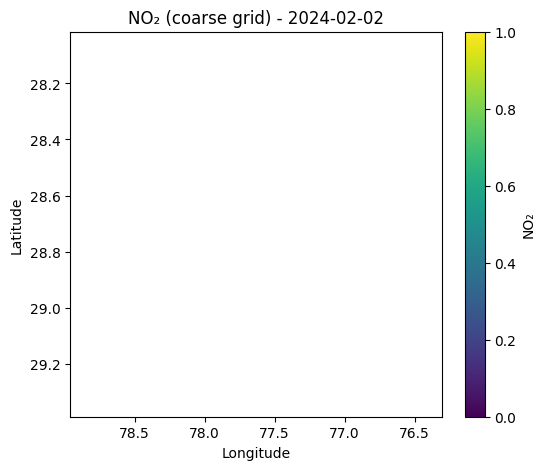

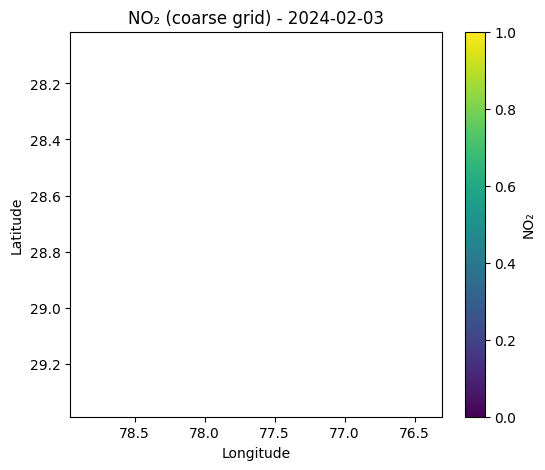

nan nan
nan nan


In [293]:
latt = []
lonn = []
print(df_merged)
for d in selected_dates:
    subset = df_merged[df_merged['date'] == d].copy()

    # Create grid
    pivot = subset.pivot_table(
        index='lat',
        columns='lon',
        values='NO2'
    )
    pivot.fillna(0.0)

    plt.figure(figsize=(6,5))
    plt.imshow(
        pivot.values,
        extent=(
            78.96056600117977, 76.30334939075422,
            29.38973199289633, 28.015309608193462
            # pivot.columns.min(), pivot.columns.max(),
            # pivot.index.min(), pivot.index.max()
        ),
        origin='lower',
        aspect='auto'
    )
    lonn += [pivot.columns.min(), pivot.columns.max()]
    latt += [pivot.index.min(), pivot.index.max()]
    plt.colorbar(label='NO₂')
    plt.title(f'NO₂ (coarse grid) - {d}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

print(max(latt), min(latt))
print(max(lonn), min(lonn))